<a href="https://colab.research.google.com/github/anshikakumawat/TechyGirl-week3-retail-analytics/blob/feature%2Fdata-preprocessing/01_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

In [3]:
data = pd.read_csv("OnlineRetail.csv", encoding="latin1")

print("Shape of data:", data.shape)
data.head()

Shape of data: (25015, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# quick look at column info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25015 entries, 0 to 25014
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    25015 non-null  object 
 1   StockCode    25015 non-null  object 
 2   Description  24904 non-null  object 
 3   Quantity     25015 non-null  int64  
 4   InvoiceDate  25015 non-null  object 
 5   UnitPrice    25015 non-null  float64
 6   CustomerID   16056 non-null  float64
 7   Country      25015 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.5+ MB


In [5]:
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
InvoiceNo         0
StockCode         0
Description     111
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     8959
Country           0
dtype: int64


In [7]:
data = data.dropna(subset=["CustomerID"])
# remove duplicate rows
data = data.drop_duplicates()
data["InvoiceNo"] = data["InvoiceNo"].astype(str)
data = data[data["InvoiceNo"].str.startswith("C") == False]
data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0]
data["CustomerID"] = data["CustomerID"].astype(int).astype(str)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

# new column: total price per row
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

print("Data after cleaning:", data.shape)
data.head()


Data after cleaning: (15348, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


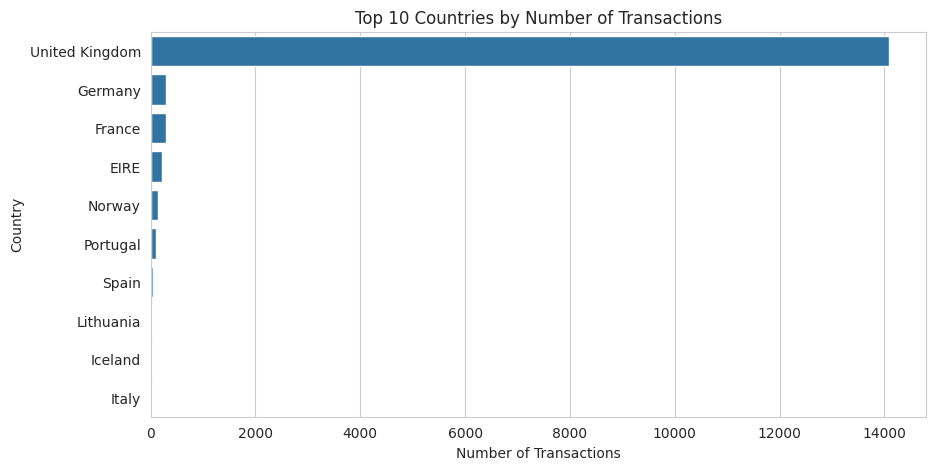

In [8]:
top_countries = data["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.show()

Rows: 392692
Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00

Months found: 13
InvoiceDate
2010-12-31     570422.730
2011-01-31     568101.310
2011-02-28     446084.920
2011-03-31     594081.760
2011-04-30     468374.331
2011-05-31     677355.150
2011-06-30     660046.050
2011-07-31     598962.901
2011-08-31     644051.040
2011-09-30     950690.202
2011-10-31    1035642.450
2011-11-30    1156205.610
2011-12-31     517190.440
Freq: ME, Name: TotalPrice, dtype: float64


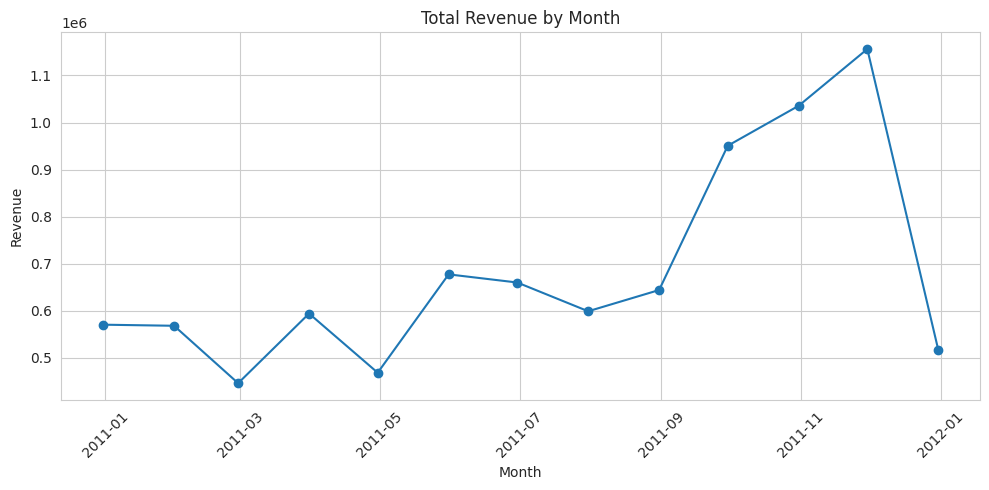

In [17]:
# datetime
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
# range
print("Rows:", len(data))
print("Min date:", data["InvoiceDate"].min())
print("Max date:", data["InvoiceDate"].max())
# monthly revenue
monthly_sales = data.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()
print("\nMonths found:", len(monthly_sales))
print(monthly_sales)
# graph
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

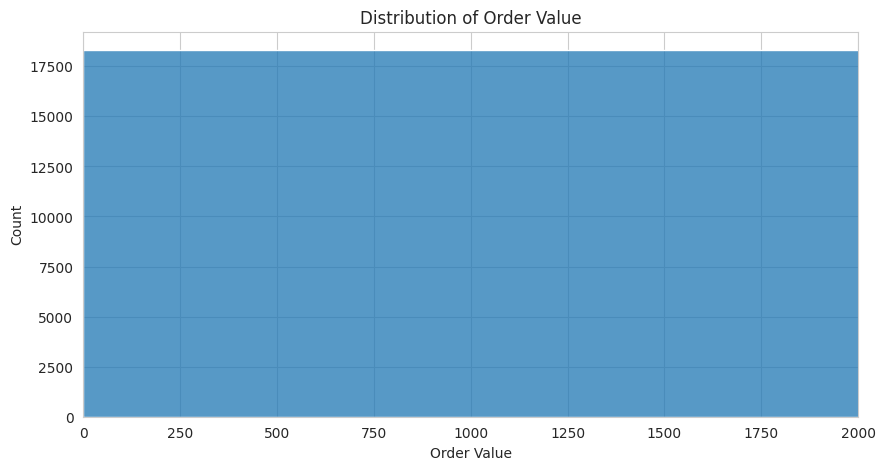

In [18]:
order_totals = data.groupby("InvoiceNo")["TotalPrice"].sum()

plt.figure(figsize=(10,5))
sns.histplot(order_totals, bins=50)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.xlim(0, 2000)   # zoom in
plt.show()

In [19]:
last_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

last_purchase = data.groupby("CustomerID")["InvoiceDate"].max().reset_index()
last_purchase.columns = ["CustomerID", "LastPurchaseDate"]
last_purchase["Recency"] = (last_date - last_purchase["LastPurchaseDate"]).dt.days

frequency = data.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequency.columns = ["CustomerID", "Frequency"]

monetary = data.groupby("CustomerID")["TotalPrice"].sum().reset_index()
monetary.columns = ["CustomerID", "Monetary"]

rfm = last_purchase[["CustomerID", "Recency"]]
rfm = rfm.merge(frequency, on="CustomerID")
rfm = rfm.merge(monetary, on="CustomerID")

print("RFM table shape:", rfm.shape)
rfm.head()


RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


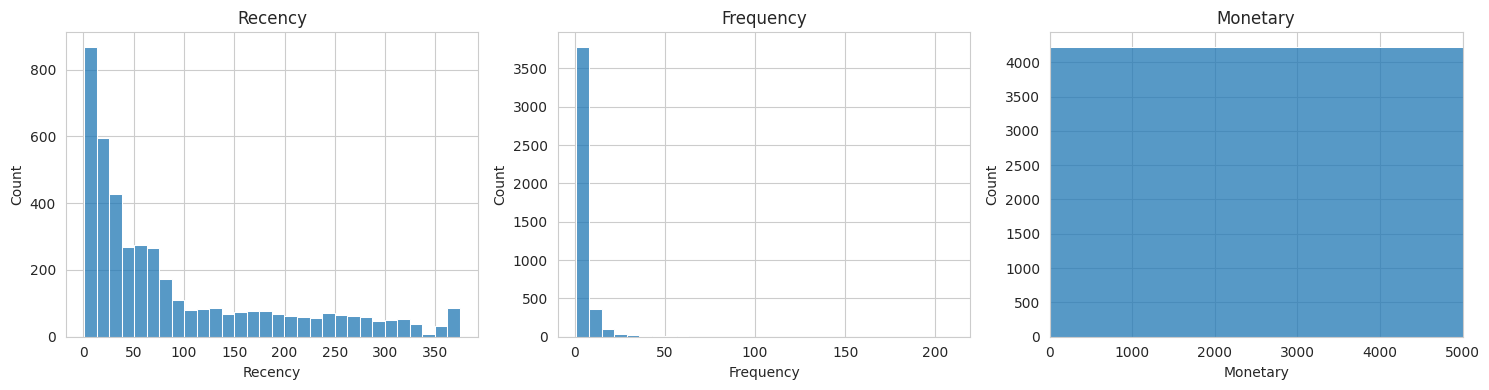

In [20]:
# RFM values
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency")
sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_xlim(0, 5000)
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()


In [21]:
# Feature 1: Avg days between orders
order_dates = data.groupby(["CustomerID", "InvoiceNo"])["InvoiceDate"].min().reset_index()
order_dates = order_dates.sort_values(["CustomerID", "InvoiceDate"])

order_dates["gap"] = order_dates.groupby("CustomerID")["InvoiceDate"].diff().dt.days
avg_gap = order_dates.groupby("CustomerID")["gap"].mean().reset_index()
avg_gap.columns = ["CustomerID", "AvgDaysBetweenOrders"]

avg_gap.head()


,CustomerID,AvgDaysBetweenOrders
0,12346.0,NaN
1,12347.0,60.333333
2,12348.0,94.000000
3,12349.0,NaN
4,12350.0,NaN


In [22]:
# Feature 2: Weekend purchase ratio
data["IsWeekend"] = data["InvoiceDate"].dt.dayofweek >= 5   # Saturday=5, Sunday=6

weekend_ratio = data.groupby("CustomerID")["IsWeekend"].mean().reset_index()
weekend_ratio.columns = ["CustomerID", "WeekendRatio"]

weekend_ratio.head()


,CustomerID,WeekendRatio
0,12346.0,0.000000
1,12347.0,0.000000
2,12348.0,0.096774
3,12349.0,0.000000
4,12350.0,0.000000


In [23]:
# Target Encoding
country_avg = data.groupby("Country")["TotalPrice"].mean()
customer_country = data.groupby("CustomerID")["Country"].agg(lambda x: x.value_counts().index[0]).reset_index()
customer_country["CountryEncoded"] = customer_country["Country"].map(country_avg)

customer_country.head()


,CustomerID,Country,CountryEncoded
0,12346.0,United Kingdom,20.861862
1,12347.0,Iceland,23.681319
2,12348.0,Finland,32.913985
3,12349.0,Italy,23.064960
4,12350.0,Norway,33.767918


In [24]:
final_table = rfm.merge(avg_gap, on="CustomerID", how="left")
final_table = final_table.merge(weekend_ratio, on="CustomerID", how="left")
final_table = final_table.merge(customer_country[["CustomerID", "CountryEncoded"]], on="CustomerID", how="left")

print("Final table shape:", final_table.shape)
print("\nMissing values:")
print(final_table.isnull().sum())

final_table.head()

Final table shape: (4338, 7)

Missing values:
CustomerID                 0
Recency                    0
Frequency                  0
Monetary                   0
AvgDaysBetweenOrders    1493
WeekendRatio               0
CountryEncoded             0
dtype: int64


,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
0,12346.0,326,1,77183.60,NaN,0.000000,20.861862
1,12347.0,2,7,4310.00,60.333333,0.000000,23.681319
2,12348.0,75,4,1797.24,94.000000,0.096774,32.913985
3,12349.0,19,1,1757.55,NaN,0.000000,23.064960
4,12350.0,310,1,334.40,NaN,0.000000,33.767918


In [25]:
num_cols = ["Recency", "Frequency", "Monetary", "AvgDaysBetweenOrders", "WeekendRatio", "CountryEncoded"]
# numeric columns
num_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
# ColumnTransformer
preprocessor = ColumnTransformer([
    ("numbers", num_pipeline, num_cols)
])
# final pipeline
final_pipeline = Pipeline([
    ("prep", preprocessor)
])
# fit + transform
final_data = final_pipeline.fit_transform(final_table)

print("Final transformed data shape:", final_data.shape)
print(final_data[:5])


Final transformed data shape: (4338, 6)
[[ 2.33457414 -0.4250965   8.36301037 -0.23371846 -0.4723229  -0.1415106 ]
 [-0.90534032  0.3544168   0.2516989  -0.09749771 -0.4723229   0.19730116]
 [-0.17535959 -0.03533985 -0.02798783  0.52787934 -0.12613866  1.30678286]
 [-0.73534481 -0.4250965  -0.03240559 -0.23371846 -0.4723229   0.12323392]
 [ 2.17457836 -0.4250965  -0.19081155 -0.23371846 -0.4723229   1.40939919]]


In [28]:
final_table.to_csv("customer_features.csv", index=False)
np.save("customer_features_scaled.npy", final_data)

print("Saved: customer_features.csv and customer_features_scaled.npy")


Saved: customer_features.csv and customer_features_scaled.npy
